# Machine Learning Models Crash Course - Unsupervised Learning
In this notebook, we will explore several unsupervised machine learning models using the Kaggle Housing dataset. As we work through each model, you will see how the same data can support different types of predictions and decisions.In unsupervised learning, we dont give any labeld data and we expect the model to come up and find patterns on its own.

*The mental shift here is significant:* There's no *y* anymore. Every model you've built so far had a target to predict and a "right answer" to check against (accuracy, recall, etc.). Unsupervised learning has neither — you're just handing the model X and asking it to find structure on its own, with no ground truth to validate against. That changes how you evaluate success entirely (no more confusion matrices). So we ask the following question: *do natural groupings exist at all, without me telling it what to look for?*

The notebook will cover the following models: 
1. **Clustering** (e.g., K-Means, DBSCAN)
2. **Dimensionality** Reduction (e.g., PCA, t-SNE)
3. **Association Rule Learning** (e.g., Apriori, Eclat)
4. **Anomaly Detection** (e.g., Isolation Forest, One-Class SVM)


----

In [32]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules


from sklearn.metrics import classification_report, confusion_matrix

In [1]:
from data_loader import load_housing_data
df = load_housing_data()

/opt/anaconda3/envs/dsproj/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1. Clustering
Sorts unlabeled data into groups based on natural similarities. Items inside a single group share high similarity, while items in different groups remain distinct.

**Core metric**: Distance or density calculations (like Euclidean distance) determine how close data points are to each other - this is the entire basis for how clustering decides what belongs together, since there's no label to check against.

**Types of clustering:**
- **Centroid-based (K-Means)**: Divides data into K groups by shifting central points (centroids) iteratively until they stabilize. You have to choose K (the number of clusters) upfront.
- **Density-based (DBSCAN)**: Finds densely packed regions of data points and groups them together, while leaving sparse/isolated points out as noise rather than forcing them into a cluster. Unlike K-Means, you don't need to specify the number of clusters in advance.

Let's ask the right question: *Do houses cluster into recognizable market segments based on their features, without me predefining what 'luxury' means the way I did earlier?*`

#### **k-means**

It needs you to pick how many groups to force the data into (that's what inertia/the elbow helps you choose)

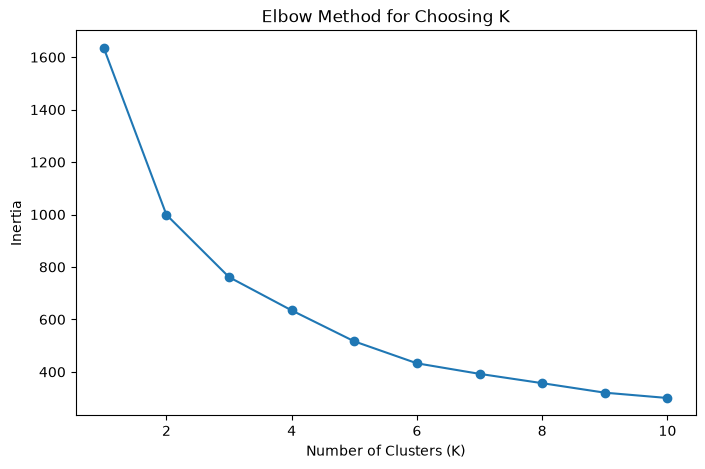

In [ ]:

# Features to cluster on - notice: no target/y involved at all
features = ['area', 'price', 'bedrooms']
X = df[features]

# Scale so no single feature dominates. Why? Because the features are on different scales (e.g., area in square feet, price in dollars, bedrooms as a count). Scaling ensures that each feature contributes equally to the distance calculations used in clustering algorithms like KMeans.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# We figure out how many clusters (K) makes sense
inertias = []   # is the sum of squared distances of samples to their closest cluster center. Lower inertia means better clustering.
K_range = range(1, 11) # is the range of K values we want to test, from 1 to 10 clusters.

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 means the algorithm will run 10 times with different centroid seeds and take the best output in terms of inertia.
    km.fit(X_scaled) # fit the KMeans algorithm to the scaled data
    inertias.append(km.inertia_) # append the inertia for this K to the list of inertias

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Choosing K')
plt.show()



### Graph Explanations

- We used the "elbow method" in the code which reflects the shape of the graph show above. This is a useful visualization technique to determine the optimal number of clusters (K) for KMeans clustering. 
- The idea is to plot the inertia (sum of squared distances of samples to their closest cluster center) against different values of K. 
- Why? Because as K increases, inertia decreases (clusters are tighter), but after a certain point, the rate of decrease slows down significantly. This point is often referred to as the "elbow" of the graph. The optimal K is typically chosen at this elbow point, where adding more clusters doesn't significantly improve the clustering quality. In this case, we can see that the elbow appears to be around K=3 or K=4, suggesting that 3 or 4 clusters may be a good choice for our data.

In [ ]:
k = 3  # adjust based on your elbow plot - this is the optimal # of clusters. 
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(df['cluster'].value_counts())

cluster
0    237
2    180
1    128
Name: count, dtype: int64


In [6]:
cluster_summary = df.groupby('cluster')[features].mean()
print(cluster_summary)

                area         price  bedrooms
cluster                                     
0        3943.907173  4.018399e+06  3.286920
1        4250.328125  3.450945e+06  1.984375
2        7379.427778  6.687700e+06  3.238889


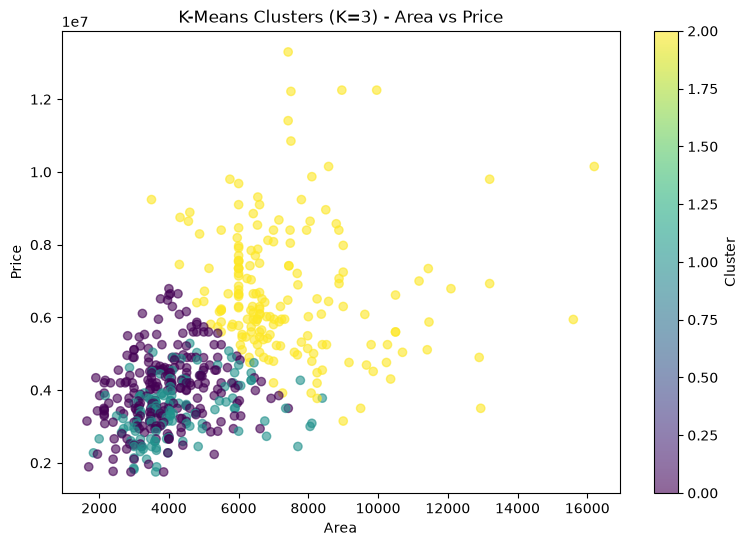

In [7]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df['area'], df['price'], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Area')
plt.ylabel('Price')
plt.title(f'K-Means Clusters (K={k}) - Area vs Price')
plt.colorbar(scatter, label='Cluster')
plt.show()

- This plot shows each house positioned by area and price, colored by the cluster K-Means assigned it to (using all three features: area, price, and bedrooms - not just the two shown here). 
- Clusters: 
    - Cluster 2 (yellow) is clearly separated in this view - it occupies the upper-right region of the plot, meaning it captures houses with both large area and high price. 
    - Clusters 0 (purple) and 1 (teal), however, appear visually mixed together in this plot, overlapping heavily in both area and price. This isn't a flaw in the clustering - it's a limitation of the plot: since it only shows 2 of the 3 features used to build the clusters, any separation happening along the third feature (bedrooms) is invisible here.

    So How can we improve it? Lets plot a different perspective...


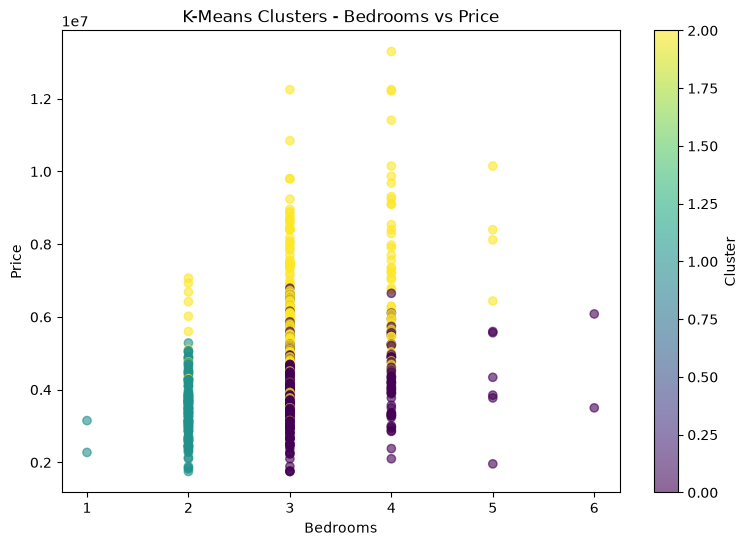

In [9]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df['bedrooms'], df['price'], c=df['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.title('K-Means Clusters - Bedrooms vs Price')
plt.colorbar(scatter, label='Cluster')
plt.show()

- This plot reveals the separation that Graph 1 couldn't show. Along the bedroom axis, teal (cluster 1) sits almost entirely at 1-2 bedrooms, while purple (cluster 0) and yellow (cluster 2) both span 3-5 bedrooms. This confirms that bedroom count is the *main feature* separating cluster 1 from cluster 0 - not area or price, which are similar between those two clusters. Meanwhile, purple and yellow occupy the same bedroom range but split clearly by price: yellow sits in the higher price band (mostly above ~$6M) at every bedroom count, while purple sits lower (mostly $2M-$6M). So the purple/yellow divide is being driven by price and area, not bedrooms.


Look at the x-axis by bedroom count:

Bedrooms = 1 and 2: almost entirely teal (cluster 1), with a bit of yellow mixed in at 2 bedrooms.
Bedrooms = 3, 4, 5, 6: overwhelmingly purple (cluster 0) and yellow (cluster 2), with teal almost completely gone.

So bedroom count is clearly doing a lot of the work separating cluster 1 (teal) from cluster 0 (purple) — teal is essentially "the low-bedroom-count cluster," which lines up exactly with the summary table showing cluster 1's average bedrooms (1.98) sitting nearly a full bedroom below cluster 0's (3.29).

### Key Insights
- **Cluster 1 (teal) = "Small households"**: ~2 bedrooms, moderate area/price. Defined mainly by low bedroom count.
- **Cluster 0 (purple) = "Mid-range family homes"**: ~3 bedrooms, moderate price/area. Similar bedroom range to yellow, but notably lower price.
- **Cluster 2 (yellow) = "Larger, higher-value homes"**: similar bedroom range to purple, but consistently larger area and higher price.
- No single feature explains the clustering on its own - it took two different 2D views, each highlighting a different pair of features, to understand how all three clusters were actually separated.

### Big Picture
- K-Means didn't simply rediscover an obvious "small/medium/large" split the way a human might guess from area and price alone. Instead, it found a genuinely multidimensional pattern: bedroom count differentiates one boundary (cluster 1 vs. the rest), while price/area differentiates another (cluster 0 vs. cluster 2) - and neither boundary is visible from a single chart. 
- This is a core reason unsupervised learning can be valuable even without a target variable: it can surface structure across several features simultaneously that isn't obvious from any one manually-chosen 2D visualization. 
- It's also a practical reminder that when working with 3+ features, you generally need multiple plots (or dimensionality reduction like PCA) to actually understand what a clustering result found - a single scatter plot can be incomplete or even misleading on its own.

#### **dbscan**

It needs you to define "how close is close enough to be neighbors" (eps) and "how many neighbors makes an area dense" (min_samples). The number of clusters is an output of DBSCAN, not an input you choose. So there's no "K" to have an elbow plot about in the first place.

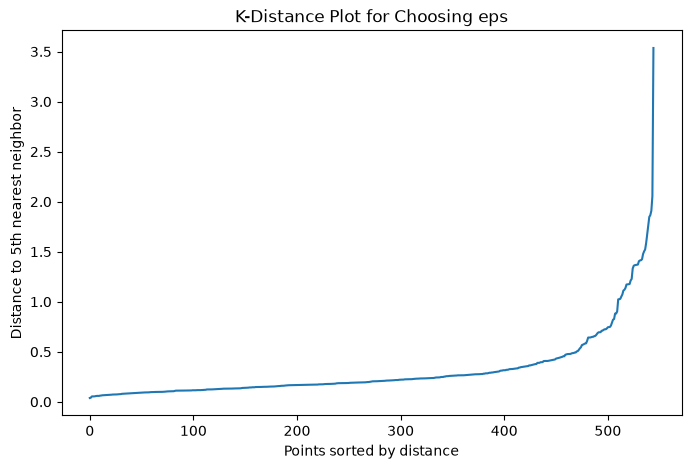

In [ ]:
min_samples = 5  # a reasonable starting point for 3 features

neighbors = NearestNeighbors(n_neighbors=min_samples)   # is the number of neighbors to consider when calculating the distance to the k-th nearest neighbor. why? Because we want to find the distance to the 5th nearest neighbor for each point in the dataset, which will help us determine a suitable value for eps in DBSCAN. The choice of min_samples is often based on the dimensionality of the data and the expected density of clusters. In this case, since we have 3 features, a common heuristic is to set min_samples to be at least the number of dimensions plus one (3 + 1 = 4), but we can use 5 as a slightly more conservative choice to ensure that we capture enough neighbors for density estimation.
neighbors_fit = neighbors.fit(X_scaled) # is the fitted NearestNeighbors model that has learned the structure of the scaled data. This model can now be used to find the nearest neighbors for each point in the dataset.
distances, indices = neighbors_fit.kneighbors(X_scaled) # is the distances to the k-th nearest neighbors for each point in the dataset. The distances array contains the distances from each point to its 5 nearest neighbors, and the indices array contains the indices of those neighbors in the original dataset. We will use these distances to create a k-distance plot, which helps us identify a suitable value for eps in DBSCAN by looking for a "knee" or "elbow" in the plot where the distance starts to increase more rapidly.

# Sort distances to the k-th nearest neighbor
distances = np.sort(distances[:, min_samples - 1]) # sorting it allows us to get the "elbow" point in the k-distance plot, here we can look for a point where the slope of the curve changes significantly, indicating a suitable value for eps.

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {min_samples}th nearest neighbor')
plt.title('K-Distance Plot for Choosing eps')
plt.show()


- Here the x-axis = individual points (sorted), y-axis = distance from each single point to its 5th nearest neighbor. It answers: "for each point, how far away do I have to look before I've found 5 neighbors?" You're not comparing cluster counts at all — you're looking at local point density across the dataset.
- The plot shows a fairly gentle, gradual rise until around point ~480-500, where it sharply bends upward toward the right edge. That bend is your elbow & it looks like it's roughly around distance ≈ 0.5–0.7, right where the curve starts steepening.

In [20]:
dbscan = DBSCAN(eps=0.6, min_samples=5)  # replace 1.0 with whatever the elbow plot suggested
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)
print(df['dbscan_cluster'].value_counts())

dbscan_cluster
 1    287
 2    126
 0     80
-1     47
 3      5
Name: count, dtype: int64


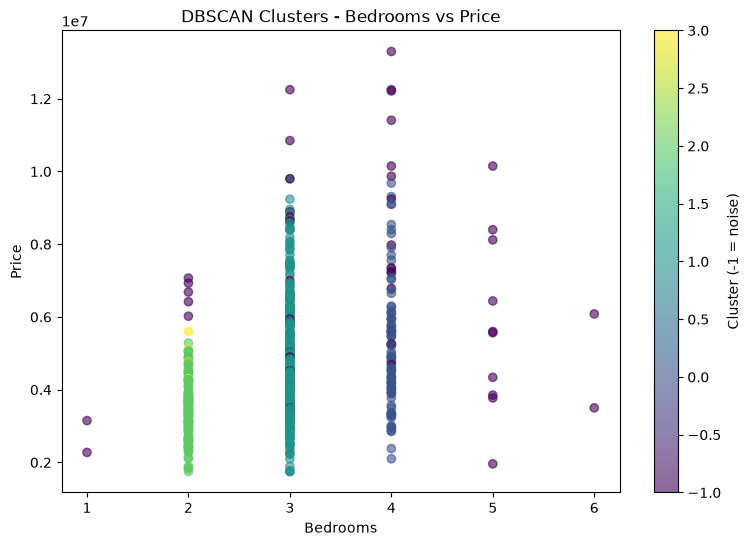

In [18]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df['bedrooms'], df['price'], c=df['dbscan_cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.title('DBSCAN Clusters - Bedrooms vs Price')
plt.colorbar(scatter, label='Cluster (-1 = noise)')
plt.show()

DBSCAN was run on the same three scaled features as K-Means (area, price, bedrooms), but works on a fundamentally different principle: rather than being told how many groups to create, it searches for regions of high point density and treats sparse, isolated points as noise. The `eps` value (0.6) was chosen using a k-distance plot, which showed where the average distance to a point's 5th-nearest neighbor sharply increased.

The result was 4 clusters (0, 1, 2, 3) plus 47 points labeled as noise (-1). Plotting bedrooms against price reveals that these clusters form almost perfectly vertical bands, each corresponding to a single bedroom count (2, 3, 4, etc.), rather than blending price and area into the grouping. Within a single cluster - e.g., all 3-bedroom houses - price ranges from roughly $2M up to $12M+, yet these houses still receive the same cluster label. This indicates that bedroom count is effectively the only feature creating real density-based separation in this dataset; price and area vary too smoothly and continuously to produce natural gaps for DBSCAN to detect.

### Key Takeaways — DBSCAN
- DBSCAN did not need to be told a target number of clusters, and it did not force every point into a group - 47 points were honestly labeled as noise rather than crammed into the nearest cluster.
- The clusters it found are driven almost entirely by bedroom count, since bedrooms is the only feature in this dataset with natural, discrete gaps (whole numbers, no in-between values). Price and area, by contrast, vary continuously with no natural density breaks for DBSCAN to latch onto.
- This is a meaningful, honest finding about the shape of the data itself, not a shortcoming of the algorithm: DBSCAN essentially reported "the only real structural separation I can find here is bedroom count" - it did not find genuine density-based sub-groups within a given bedroom count based on price or area.


In [19]:
comparison = pd.crosstab(df['cluster'], df['dbscan_cluster'])
print(comparison)

dbscan_cluster  -1   0    1    2   3
cluster                             
0                8  50  179    0   0
1                2   0    0  126   0
2               37  30  108    0   5


---
## Graph Explanation — K-Means vs. DBSCAN Compared


Both methods were run on the identical scaled features (area, price, bedrooms) and both show some relationship to bedroom count when plotted against price - so at a glance, the two results can look similar. The real difference emerges when looking at bedroom counts of 3 and 4 specifically: K-Means splits houses at the same bedroom count into different clusters based on price (low-price houses in one cluster, high-price houses in another), while DBSCAN places nearly all houses at a given bedroom count into a single cluster, regardless of whether the house is priced at $2M or $12M. This can be confirmed numerically by comparing price variance within each cluster - DBSCAN's clusters show far higher internal price spread than K-Means' clusters, since K-Means is actively using price (and area) to draw boundaries, while DBSCAN's boundaries are driven almost entirely by bedroom count alone.

### Key Takeaways — K-Means vs. DBSCAN
- K-Means blends all three features (area, price, bedrooms) together when forming its 3 clusters, producing groups that combine a "family size" signal (bedrooms) with a "value tier" signal (price/area).
- DBSCAN, left to find density on its own terms, concluded that only bedroom count creates real separable structure - price and area contribute noise points at the extremes but don't create genuine sub-clusters within a bedroom count.
- Because K-Means always returns exactly K clusters (whether or not natural groupings truly exist), and DBSCAN only returns clusters where real density gaps exist, the two methods answering different questions: K-Means answers "if I must split this data into 3 groups using all these features together, what's the best way to do it?" while DBSCAN answers "does this data have any natural density-based structure at all, and if so, what is it?"

### Big Picture
Together, these two results tell a coherent story about this dataset: bedroom count is a genuinely strong, discrete signal that both methods detect in some form, but price and area behave as smooth, continuous variables without natural breakpoints. K-Means' forced structure makes the data look more segmented than it may truly be (imposing "3 market tiers" whether or not they naturally exist), while DBSCAN's unforced approach reveals that most of that apparent tiering is really just riding on top of bedroom count, with price/area adding gradual variation rather than distinct sub-populations. This is a useful, general lesson for unsupervised learning: the choice of algorithm doesn't just change the *output*, it changes the *question being asked* - and comparing multiple methods on the same data can reveal how much of a "discovered pattern" is a real property of the data versus an artifact of the algorithm's own assumptions.

---
## 2. Dimensionality Reduction

The process of reducing the number of input variables or features in a dataset while retaining as much critical information as possible.

**Why it matters:**
- **The Curse of Dimensionality**: As features increase, data becomes sparse, distances between points lose meaning, and models require exponentially more data to learn patterns.
- **Overfitting Prevention**: Fewer features stop a model from memorizing random noise, improving its ability to generalize to new data.

**Core Concept**: Dimensionality reduction methods are evaluated by how well they preserve the original information despite compressing it - this is tracked differently depending on the method: the percentage of data variance retained (Explained Variance in PCA), the accuracy of data reconstruction (Reconstruction Error), or how well local neighbor relationships are maintained (Trustworthiness in t-SNE).

**Types of dimensionality reduction:**
- **Linear Methods**: Transform data using straight-line projections (e.g., PCA, LDA, MDS).
- **Non-Linear Methods / Manifold Learning**: Map complex, curving structures that linear methods miss (e.g., t-SNE, UMAP, Isomap).
- **Deep Learning Methods**: Use neural networks to find highly intricate, non-linear compressions (e.g., Autoencoders, VAEs).
- **Feature Selection Methods**: Keep a subset of the *original* features rather than creating new ones (e.g., Filter, Wrapper, Embedded methods).

**One important distinction**: the first three categories all *create new features* by combining/transforming the original ones (e.g. PCA's "component 1" is a blend of several original columns and no longer has a direct real-world meaning on its own). Feature selection is different - it doesn't transform anything, it simply picks which original, still-interpretable columns to keep and which to drop.

A question we can ask: *Do these 12 features actually contain 12 independent pieces of information, or are many of them just different reflections of a smaller number of underlying patterns?*
- *"Is a house's character really described by 12 separate, independent things — or are bedrooms, bathrooms, stories, parking, airconditioning, prefarea, etc. actually just different symptoms of a smaller number of real underlying factors like 'overall house size' and 'luxury/amenity level' — that happen to show up across many columns at once?*

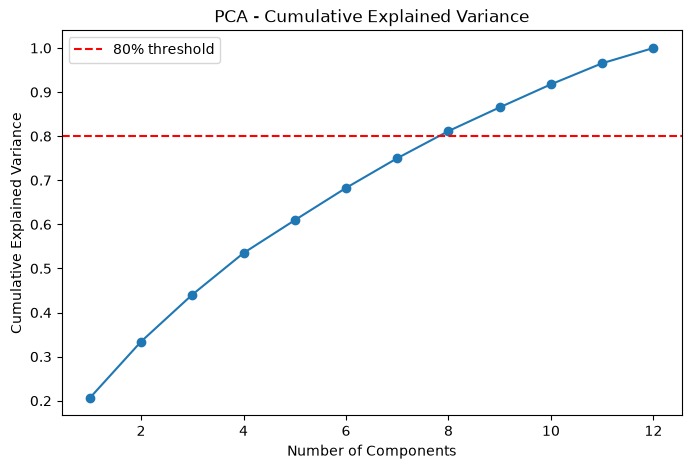

Explained variance per component: [0.20622765 0.1278482  0.10650708 0.09434955 0.07455508 0.07314426
 0.06737316 0.0615989  0.05378615 0.05224405 0.04777492 0.03459102]


In [ ]:
# PCA only works on numbers, so the yes/no and furnishing columns need encoding first:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    df[col + '_encoded'] = (df[col] == 'yes').astype(int)

# Ordinal encoding for furnishing status (same logic as before)
furnish_map = {'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2}
df['furnishingstatus_encoded'] = df['furnishingstatus'].map(furnish_map)


# these are all the features in th eoriginal dataset. since PCS does better with more information, we will include all of them. the target variable (price) is not included, since PCA is unsupervised and does not use the target variable.
pca_features = [            
    'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
    'mainroad_encoded', 'guestroom_encoded', 'basement_encoded',
    'hotwaterheating_encoded', 'airconditioning_encoded', 'prefarea_encoded',
    'furnishingstatus_encoded'
]

X_pca_input = df[pca_features]      # this is the input data for PCA, which includes all the features we want to reduce dimensionality for.
X_pca_scaled = scaler.fit_transform(X_pca_input)        # this scales the input data so that each feature contributes equally to the PCA transformation. Scaling is important because PCA is sensitive to the variances of the original features, and features with larger scales can dominate the principal components.


pca = PCA() # this initializes the PCA model without specifying the number of components, which means it will compute all principal components.
X_pca = pca.fit_transform(X_pca_scaled) # this fits the PCA model to the scaled input data and transforms it into the principal component space. The result, X_pca, is a new representation of the data in terms of its principal components, which are linear combinations of the original features that capture the maximum variance in the data.

explained_var = pca.explained_variance_ratio_ # this gives the proportion of variance explained by each principal component. It tells us how much information (variance) is captured by each component, which helps us decide how many components to keep for dimensionality reduction while retaining most of the original information.
cumulative_var = explained_var.cumsum() # this computes the cumulative sum of the explained variance ratios, which allows us to see how much total variance is explained as we include more principal components. It helps us determine the number of components needed to reach a desired level of explained variance (e.g., 80% or 90%).

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_var) + 1), cumulative_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
plt.legend()
plt.show()

print("Explained variance per component:", explained_var)


This tells you how many components you'd actually need to keep most of the information — e.g., if you want to keep 80% of the variance, you can look at the cumulative explained variance plot and see how many components you need to reach that threshold. 
In this case, it looks like you would need around 6 components to capture 80% of the variance in the data.

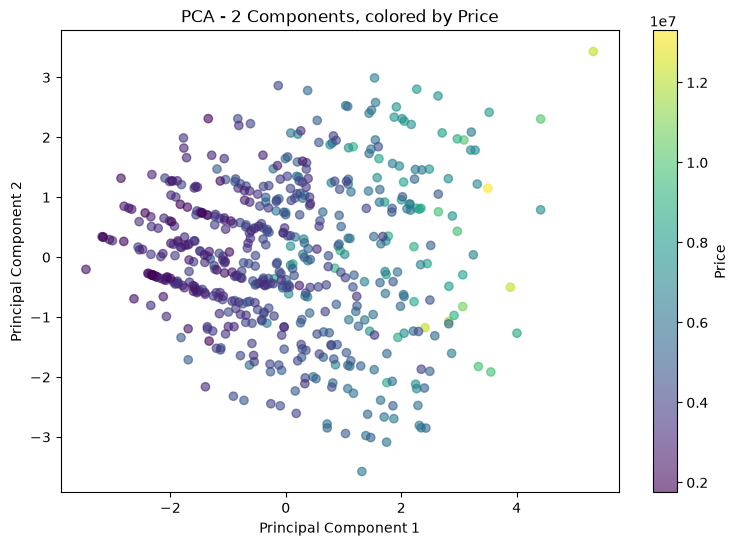

Variance explained by 2 components: 33.41%


In [25]:
pca_2d = PCA(n_components=2) # this initializes a new PCA model that will reduce the data to 2 principal components. By specifying n_components=2, we are telling PCA to find the two directions (components) in the feature space that capture the most variance in the data. This is useful for visualization and for reducing dimensionality while retaining as much information as possible. 
# Why two? Because we want to visualize the data in a 2D scatter plot, which requires two dimensions. By reducing the data to two principal components, we can plot the transformed data points on a 2D plane, making it easier to observe patterns, clusters, or relationships between the features while still capturing a significant amount of the original variance in the dataset.
X_pca_2d = pca_2d.fit_transform(X_pca_scaled) # this fits the model (same as before)

# created the 2d PCA features and added them to the dataframe so we can visualize them in a scatter plot. The first principal component is stored in 'pca1' and the second in 'pca2'.
df['pca1'] = X_pca_2d[:, 0]
df['pca2'] = X_pca_2d[:, 1]

plt.figure(figsize=(9, 6))
scatter = plt.scatter(df['pca1'], df['pca2'], c=df['price'], cmap='viridis', alpha=0.6)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA - 2 Components, colored by Price')
plt.colorbar(scatter, label='Price')
plt.show()

print(f"Variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.2%}")

In [26]:
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=pca_features
)
print(loadings)

                               PC1       PC2
area                      0.378818 -0.144041
bedrooms                  0.342687  0.350771
bathrooms                 0.363868  0.272658
stories                   0.308441  0.499779
parking                   0.310754 -0.063720
mainroad_encoded          0.259664 -0.206680
guestroom_encoded         0.245620 -0.346088
basement_encoded          0.176707 -0.474612
hotwaterheating_encoded   0.006247  0.091073
airconditioning_encoded   0.331501  0.103638
prefarea_encoded          0.258911 -0.337353
furnishingstatus_encoded  0.281091 -0.086243


### Q: So what to do with the 8  number of components?

In [27]:
pca_8 = PCA(n_components=8)
X_pca_8d = pca_8.fit_transform(X_pca_scaled)

print(f"Shape before PCA: {X_pca_scaled.shape}")   # (545, 12)
print(f"Shape after PCA:  {X_pca_8d.shape}")        # (545, 8)
print(f"Variance retained: {pca_8.explained_variance_ratio_.sum():.2%}")

Shape before PCA: (545, 12)
Shape after PCA:  (545, 8)
Variance retained: 81.16%


### X_pca_8d is now a brand new feature matrix with the same 545 houses, but only 8 columns instead of 12. Those 8 columns are no longer "bedrooms," "bathrooms," etc. — they're new blended variables (PC1 through PC8), each some mathematical mixture of the originals.

### You can now redo your random forest classification (in the supervised learning notebook) for super_rentable, but using the 8 PCA components instead of the raw features!

### Why?
- Speed — fewer input columns means faster training, which matters a lot more on large datasets than this small one, but it's the core motivation.
- Reducing the curse of dimensionality — from your earlier notes, more features can mean sparser data and models needing exponentially more examples; compressing to fewer, denser components can sometimes help a model generalize better.
- Removing redundancy/multicollinearity — if bedrooms, bathrooms, and stories are all highly correlated (bigger houses tend to have more of all three), feeding a model all three separately is partly redundant information; PCA blends that redundancy into fewer, cleaner signals.


3. **Association Rule Learning** (e.g., Apriori, Eclat)
4. **Anomaly Detection** (e.g., Isolation Forest, One-Class SVM)

---
## 3. Association Rule Learning (e.g., Apriori, Eclat)

Used to discover interesting relationships and hidden patterns among items in large datasets. It is most famous for Market Basket Analysis, where it uncovers rules like "If a customer buys diapers, they are 80% likely to also buy beer."

**Core Metrics:**
- **Support**: Measures how frequently an itemset appears in the dataset.
- **Confidence**: Measures how often the rule is found to be true (the conditional probability of buying item Y given that item X was bought).
- **Lift**: Measures how much more likely item Y is bought with item X compared to if they were independent. A lift greater than 1 means the items are positively associated.

**Main Techniques:**
- **Apriori Algorithm**: The classic, iterative approach. It uses a bottom-up strategy where frequent subsets are extended one item at a time, cutting off combinations that don't meet a minimum support threshold.
- **Eclat (Equivalence Class Transformation)**: A faster, vertical data-scanning depth-first search method. It relies entirely on calculating the intersection of transaction IDs, making it highly efficient for certain datasets.
- **FP-Growth (Frequent Pattern Growth)**: A modern, high-speed alternative to Apriori. It compresses the dataset into a tree structure (FP-Tree) to find frequent patterns without expensive and repeated database scans.


**Question to ask**: *"if a house has a basement, how often does it also have a guestroom, and is that association stronger than chance (lift > 1)?"*

Note: association rule learning needs transactional data — rows representing "baskets" of items bought/present together (like a shopping cart). The housing dataset doesn't naturally fit that shape; it's one row per house with various attributes, not a list of items per transaction. But we can force-fit this dataset into that shape for learning purposes. We can treat each house's yes/no amenities (guestroom, basement, airconditioning, prefarea, hotwaterheating, mainroad) as its "basket of items. That reframes your binary columns as a transaction-style dataset Apriori could actually run on.

In [ ]:
# Treat each house's amenities as a "basket" of items it "contains"
basket_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
# Convert yes/no to True/False (mlxtend's apriori expects boolean-style data)
basket_df = df[basket_cols].apply(lambda col: col == 'yes')

print(basket_df.head())

   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0      True      False     False            False             True      True
1      True      False     False            False             True     False
2      True      False      True            False            False      True
3      True      False      True            False             True      True
4      True       True      True            False             True     False


In [ ]:

# min_support=0.1 means: only keep itemsets that appear in at least 10% of houses
frequent_itemsets = apriori(basket_df, min_support=0.1, use_colnames=True) # this generates frequent itemsets from the basket_df using the Apriori algorithm. The min_support parameter is set to 0.1, meaning that only itemsets that appear in at least 10% of the houses will be considered frequent. The use_colnames=True argument ensures that the resulting DataFrame will use the original column names (amenities) instead of their encoded indices.
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False)
# we see the frequent itemsets that appear in at least 10% of the houses, sorted by their support values in descending order. This helps us identify common combinations of amenities that are often found together in the dataset.

print(frequent_itemsets)

     support                                          itemsets
0   0.858716                             frozenset({mainroad})
2   0.350459                             frozenset({basement})
3   0.315596                      frozenset({airconditioning})
6   0.308257                   frozenset({mainroad, basement})
7   0.288073            frozenset({mainroad, airconditioning})
4   0.234862                             frozenset({prefarea})
8   0.231193                   frozenset({mainroad, prefarea})
1   0.177982                            frozenset({guestroom})
5   0.165138                  frozenset({mainroad, guestroom})
9   0.130275                  frozenset({guestroom, basement})
11  0.128440                   frozenset({prefarea, basement})
14  0.126606         frozenset({mainroad, prefarea, basement})
10  0.121101            frozenset({basement, airconditioning})
12  0.121101        frozenset({mainroad, guestroom, basement})
13  0.108257  frozenset({mainroad, basement, airconditi

In [33]:
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)
rules = rules.sort_values('lift', ascending=False)

print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                               antecedents  \
24                  frozenset({guestroom})   
21         frozenset({mainroad, basement})   
20        frozenset({mainroad, guestroom})   
25                   frozenset({basement})   
9                    frozenset({basement})   
8                   frozenset({guestroom})   
13         frozenset({mainroad, basement})   
16                   frozenset({prefarea})   
12         frozenset({mainroad, prefarea})   
17                   frozenset({basement})   
10                   frozenset({prefarea})   
11                   frozenset({basement})   
14         frozenset({prefarea, basement})   
15                   frozenset({mainroad})   
5                    frozenset({prefarea})   
4                    frozenset({mainroad})   
26         frozenset({mainroad, basement})   
31            frozenset({airconditioning})   
19            frozenset({airconditioning})   
18                   frozenset({basement})   
22        frozenset({guestroom, ba

### Data Explanation

Looking at the top rules by lift:
- `guestroom`, `basement`, and `mainroad` keep showing up together across the top rules, all with lift well above 2. This strongly suggests these three amenities cluster together in real houses - likely because they're all associated with a certain "type" of property (bigger lots on a main road tend to have room for both a guestroom and a basement).
- `prefarea` also shows up meaningfully (rows 13, 16, 12), with lift around 1.5-1.7 - a real but weaker association than the guestroom/basement/mainroad cluster.
- `airconditioning` sits noticeably lower (rows 26, 31, 19, 18 - lift around 1.08-1.15), much closer to 1 than the top rules. That tells us AC is much more independent from these other amenities than we might have guessed - having a basement or guestroom doesn't meaningfully predict whether a house also has air conditioning, unlike the tight guestroom-basement-mainroad relationship.

Association rules make this explicit as "if X, then Y" probabilities: guestroom, basement, and mainroad access aren't independent features - they're symptoms of the same underlying "bigger/more developed property" pattern, while airconditioning behaves more like its own separate signal.

**Caveat**: `mainroad` has very high baseline support on its own (85.9%, from the frequent itemsets table), meaning most houses in this dataset have mainroad access regardless of anything else. Because it's so common, some of the "mainroad" associations may look more impressive than they really are - it's easier for anything to "associate" with a feature that's already present in 86% of the data.

**Sanity check**: to verify this isn't just an artifact of mainroad's high baseline, it's worth examining a rule that doesn't involve mainroad at all - like row 22, `{guestroom, basement}` → `{airconditioning}` - to see whether guestroom and basement alone say anything meaningful about air conditioning, without mainroad's prevalence inflating the picture.